# **Practical - 4**

# **Exploratory Data Analysis (EDA)**

# Problem Definition
Students will explore air quality datasets by computing descriptive statistics, handling missing values, analyzing correlations among pollutants, and generating meaningful visualizations to identify trends and patterns.

**Objectives:**

* To explore real-world environmental datasets
* To understand pollution patterns across cities and seasons
* To apply EDA techniques effectively

**Tools** :
* Python
* Pandas
* Matplotlib
* Seaborn
* Scikit-learn

#**Setup & Library Imports**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **1. Load Dataset**

In [ ]:
# Load dataset
file_path = "/content/drive/MyDrive/Colab Notebooks/Pract_4/city_day.csv"
df = pd.read_csv(file_path)
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


## **2.Dataset Overview**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [ ]:
df.shape

(29531, 16)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [ ]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df['Season'] = df['Month'].apply(get_season)


## **3.Missing Values Ananlysis**

In [ ]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


In [ ]:
(df.isnull().mean() * 100).sort_values(ascending=False)

,0
Xylene,61.322001
PM10,37.723071
NH3,34.973418
Toluene,27.229014
Benzene,19.041008
AQI_Bucket,15.851139
AQI,15.851139
PM2.5,15.570079
NOx,14.171549
O3,13.619586


In [ ]:
pollutant_cols = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']

for col in pollutant_cols:
    df[col] = df[col].fillna(df[col].mean())

## **4.Descriptive Statistics**

In [ ]:
df[pollutant_cols].describe()

,PM2.5,PM10,NO2,SO2,CO,O3
count,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000
mean,67.450578,118.127103,28.560659,14.531977,2.248598,34.491430
std,59.414476,71.500953,22.941051,16.909088,6.715753,20.163443
min,0.040000,0.010000,0.010000,0.010000,0.000000,0.010000
25%,32.150000,79.315000,12.980000,6.090000,0.540000,20.740000
50%,58.030000,118.127103,25.240000,10.480000,0.950000,34.491430
75%,72.450000,118.127103,34.665000,14.531977,1.710000,42.730000
max,949.990000,1000.000000,362.210000,193.860000,175.810000,257.730000


In [ ]:
city_pollution = df.groupby('City')[pollutant_cols].mean()
city_pollution.head()


,PM2.5,PM10,NO2,SO2,CO,O3
City,,,,,,
Ahmedabad,67.728234,117.409318,49.805675,42.281148,16.147420,37.565152
Aizawl,18.020630,24.191567,0.388496,7.378053,0.283628,6.159494
Amaravati,39.614400,78.777456,22.545012,14.277044,0.793211,37.905530
Amritsar,56.724459,115.353495,18.883865,9.027176,0.656948,23.553460
Bengaluru,38.118529,89.494244,27.996732,5.545939,1.840878,32.984443


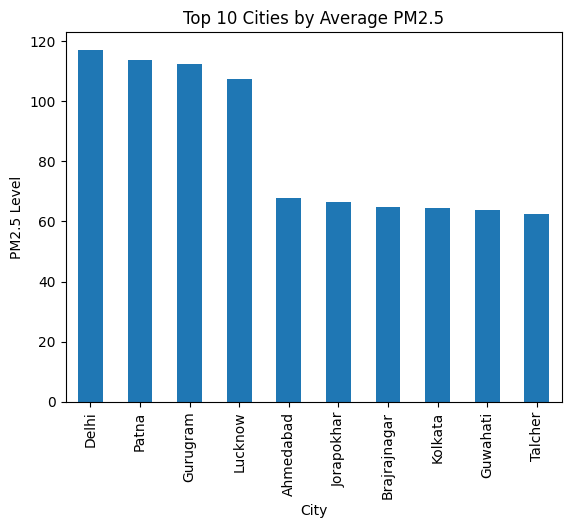

In [ ]:
city_pollution['PM2.5'].sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Cities by Average PM2.5")
plt.ylabel("PM2.5 Level")
plt.show()

## Seasonal Pollution Trend

In [ ]:
seasonal_pollution = df.groupby('Season')[pollutant_cols].mean()
seasonal_pollution

,PM2.5,PM10,NO2,SO2,CO,O3
Season,,,,,,
Monsoon,43.787074,93.800868,22.846401,11.952403,2.040041,28.053627
Post-Monsoon,89.292837,135.580277,35.357494,16.112448,2.776010,36.615071
Summer,57.558710,112.420156,25.416609,14.703103,1.786320,38.447140
Winter,95.097589,144.587966,35.163266,16.636969,2.708363,36.914023


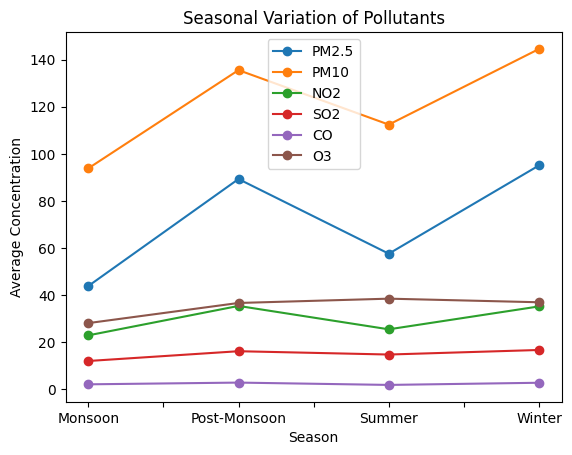

In [ ]:
seasonal_pollution.plot(marker='o')
plt.title("Seasonal Variation of Pollutants")
plt.ylabel("Average Concentration")
plt.show()

## **5. Correlation Analysis Among Pollutants**

In [ ]:
corr_matrix = df[pollutant_cols].corr()


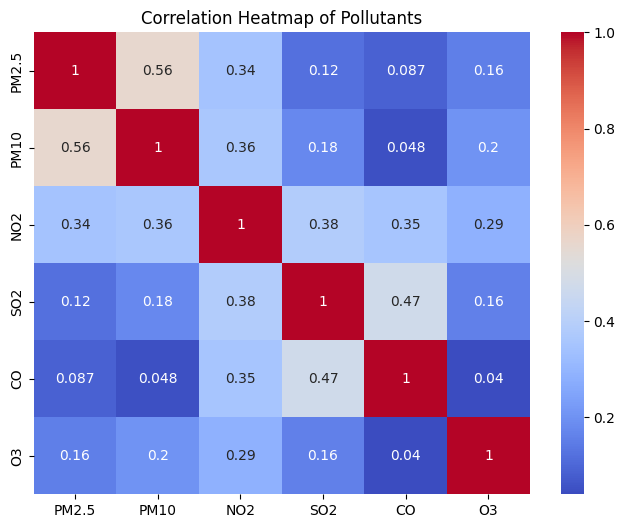

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Pollutants")
plt.show()


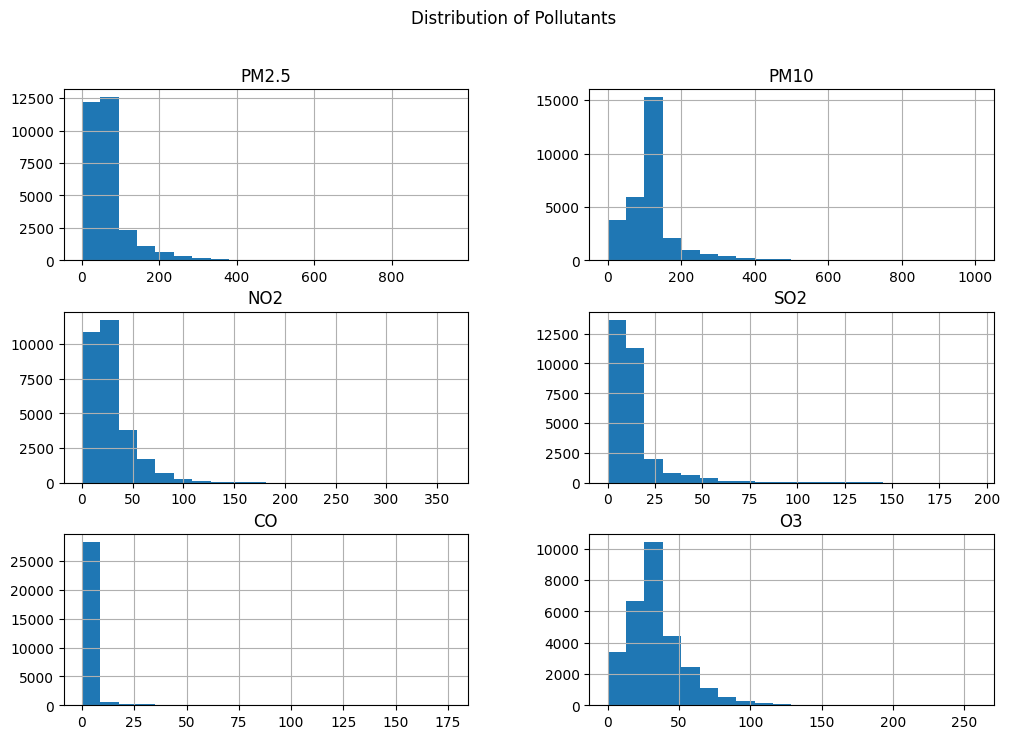

In [ ]:
df[pollutant_cols].hist(bins=20, figsize=(12,8))
plt.suptitle("Distribution of Pollutants")
plt.show()


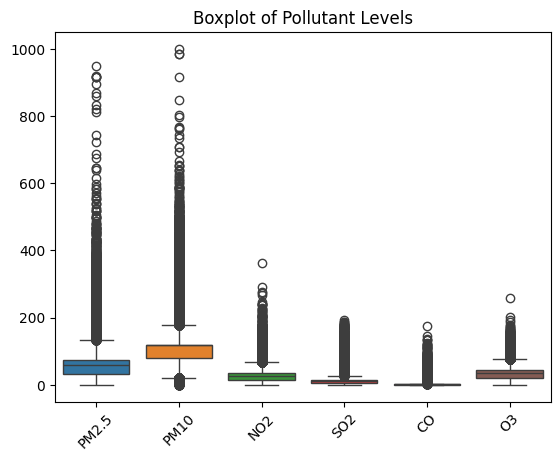

In [ ]:
sns.boxplot(data=df[pollutant_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Pollutant Levels")
plt.show()


# **Key Insights:**
* Winter has highest pollution - cold air traps pollutants like a lid on a pot.
* Northern cities are more polluted due to more vehicles, industries, and crop burning.
* PM2.5 (tiny dust particles) are most dangerous - they enter lungs and bloodstream.
* Monsoon season has cleanest air - rain washes away pollutants.
* Pollutants rise together - they share common sources like cars and factories.

# **Conclusion:**
Air quality in India varies dramatically by season and location. Winter months and northern cities face severe pollution, primarily from PM2.5 particles. Monsoon rains provide natural relief. Understanding these patterns helps identify when and where pollution control measures are most needed to protect public health.

## **Key Questions**
* ### How do pollution levels vary across cities and seasons?
Northern cities have significantly higher pollution than southern cities due to more vehicles and industries. Winter shows worst air quality as cold air traps pollutants, while monsoon has the cleanest air as rain washes pollutants away.
* ### What relationships exist between pollutants?
Strong positive correlations: PM2.5 and PM10 correlate most with AQI. Nitrogen oxides (NO, NO2, NOx) rise together. Pollutants increase simultaneously due to shared sources (vehicles, factories, burning).